Implementation of lattice Boltzmann method in python 3. It has been made faster using numba. Lets first import few things

In [42]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import time
dtype = np.float64
jit_parallel = nb.njit(nogil=True,parallel=True)

Lattice Parameters for D2Q9 lattice

In [43]:
ex = np.array([0, 1, 0, 1, 1, -1, 0, -1, -1],dtype= dtype)
ey = np.array([0, 0, 1, 1, -1, 0, -1, -1, 1],dtype= dtype)
es = (1/3)**0.5
w0 = 4/9
ws = 1/9
wl = 1/36
w = np.array([w0,ws,ws,wl,wl,ws,ws,wl,wl],dtype= dtype)

Function to compute macroscopic variables

$\rho = \sum_i f_i$

$u = 1/\rho \sum_i f_i \cdot e_i$

In [44]:
@jit_parallel
def compute_macro_vars(f,nodetype,rho,u):
    global ex,ey
    ny,nx = nodetype.shape
    for i in nb.prange(ny):
        for j in range(nx):
            if nodetype[i,j]<=0:
                rho[i,j]=f[i,j,0]+f[i,j,1]+f[i,j,2]+f[i,j,3]+f[i,j,4]+f[i,j,5]+f[i,j,6]+f[i,j,7]+f[i,j,8]
                fdotex= f[i,j,1] + f[i,j,3] + f[i,j,4] - f[i,j,5] - f[i,j,7] - f[i,j,8]
                fdotey= f[i,j,2] + f[i,j,3] - f[i,j,4] - f[i,j,6] - f[i,j,7] + f[i,j,8]
                u[0,i,j]= fdotex/rho[i,j]
                u[1,i,j]= fdotey/rho[i,j]                
            else:
                rho[i,j]=0
                u[:,i,j]=0

Function to compute Equilibrium distribution function

In [45]:
@jit_parallel
def compute_edf(rho,u,nodetype):
    global ex,ey,w,dtype
    ny,nx = nodetype.shape
    feq = np.zeros((ny,nx,9),dtype=dtype)
    for i in nb.prange(ny):
        for j in range(nx):
            if nodetype[i,j]<=0:
                for q in range(9):
                    Termorder1  = (1./es**2)*(ex[q]*u[0,i,j] + ey[q]*u[1,i,j])
                    euxy        = ex[q]*ey[q]*u[0,i,j]*u[1,i,j]
                    euxx        = ex[q]*ex[q]*u[0,i,j]*u[0,i,j]
                    euyy        = ey[q]*ey[q]*u[1,i,j]*u[1,i,j]
                    eu2         = 2*euxy + euxx + euyy
                    ux2         = u[0,i,j]*u[0,i,j]
                    uy2         = u[1,i,j]*u[1,i,j]
                    u2          = ux2+uy2
                    Termorder2  =(0.5/es**4)*eu2 - (0.5/es**2)*u2     
                    feq[i,j,q]= w[q]*rho[i,j]*(1+ Termorder1+ Termorder2)     
    return feq

Performs SRT collision step and applies forcing

$f_{c} = f - \frac{1}{\tau}(f-f_{eq})$

Forcing is applied as

$u = \frac{F \tau}{\rho}$

In [46]:
@jit_parallel
def collide(f,rho,u,nodetype,tau,Fg):
    global ex,ey,w,dtype
    ny,nx = nodetype.shape
    for i in nb.prange(ny):
        feq = [0.]*9
        for j in range(nx):
            if nodetype[i,j]<=0:
                #apply forcing
                u[0,i,j]+=Fg[0,i,j]*tau[i,j]/rho[i,j]
                u[1,i,j]+=Fg[1,i,j]*tau[i,j]/rho[i,j]
                #compute equilibrium distribution function
                feq[0]= rho[i, j]*(-2.0/3.0*u[0,i, j]**2 - 2.0/3.0*u[1,i, j]**2 + 4.0/9.0)
                feq[1]= rho[i, j]*((1.0/3.0)*u[0,i, j]**2 + (1.0/3.0)*u[0,i, j] - 1.0/6.0*u[1,i, j]**2 + 1.0/9.0)
                feq[2]= rho[i, j]*(-1.0/6.0*u[0,i, j]**2 + (1.0/3.0)*u[1,i, j]**2 + (1.0/3.0)*u[1,i, j] + 1.0/9.0)
                feq[3]= rho[i, j]*(-1.0/24.0*u[0,i, j]**2 + (1.0/12.0)*u[0,i, j] - 1.0/24.0*u[1,i, j]**2 + ( 
                1.0/12.0)*u[1,i, j] + (1.0/8.0)*(u[0,i, j] + u[1,i, j])**2 + 1.0/36.0)
                feq[4]= rho[i, j]*(-1.0/24.0*u[0,i, j]**2 + (1.0/12.0)*u[0,i, j] - 1.0/24.0*u[1,i,j]**2 - 
                1.0/12.0*u[1,i,j] + (1.0/8.0)*(u[0,i,j] - u[1,i,j])**2 + 1.0/36.0)
                feq[5]= rho[i,j]*((1.0/3.0)*u[0,i,j]**2 - 1.0/3.0*u[0,i,j] - 1.0/6.0*u[1,i,j]**2 + 1.0/9.0)
                feq[6]= rho[i,j]*(-1.0/6.0*u[0,i,j]**2 + (1.0/3.0)*u[1,i,j]**2 - 1.0/3.0*u[1,i,j] + 1.0/9.0)
                feq[7]= rho[i,j]*(-1.0/24.0*u[0,i,j]**2 - 1.0/12.0*u[0,i,j] - 1.0/24.0*u[1,i,j]**2 - 
                1.0/12.0*u[1,i,j] + (1.0/8.0)*(-u[0,i,j] - u[1,i,j])**2 + 1.0/36.0)
                feq[8]= rho[i,j]*(-1.0/24.0*u[0,i,j]**2 - 1.0/12.0*u[0,i,j] - 1.0/24.0*u[1,i,j]**2 + ( 
                1.0/12.0)*u[1,i,j] + (1.0/8.0)*(-u[0,i,j] + u[1,i,j])**2 + 1.0/36.0)
                #collision
                for q in range(9):
                    f[i,j,q]=(1.0-(1.0/(tau[i,j])))*f[i,j,q] +(1.0/(tau[i,j]))*feq[q]   
                #swap
                for q in range(1,5):
                    fswap = f[i,j,q]
                    f[i,j,q]=f[i,j,q+4]
                    f[i,j,q+4]=fswap

Performs streaming step alongwith bounceback

In [47]:
@jit_parallel
def stream_and_bounce(f,nodetype):
    global ex,ey,dtype
    ny,nx = nodetype.shape
    for i in nb.prange(ny):
        for j in range(nx):
            if nodetype[i,j]<=0:
                for q in range(1,5):
                    nexti = int(i-ey[q])
                    nextj = int(j+ex[q])
                    if nexti > ny-1: nexti = int(0)
                    if nextj > nx-1: nextj = int(0)                        
                    if nodetype[nexti,nextj]<=0:
                        fswap = f[nexti,nextj,q]
                        f[nexti,nextj,q] = f[i,j,q+4]
                        f[i,j,q+4] = fswap

Lets test our implementation

In [48]:
def test_lb():
    import time
    nx=1000
    ny=500
    niters=50000
    rho =np.ones((ny,nx), dtype = dtype)
    tau =np.ones((ny,nx), dtype = dtype)
    u  =np.zeros((2,ny,nx),dtype = dtype)
    Fg = np.zeros((2,ny,nx),dtype = dtype)
    Fg[0,:,:]=1e-4
    nodetype  =np.zeros((ny,nx),dtype = dtype)
    nodetype[0,:]=1
    nodetype[-1,:]=1
    f=compute_edf(rho,u,nodetype)
    t0 = time.time()
    for i in range(niters):
        collide(f,rho,u,nodetype,tau,Fg)
        stream_and_bounce(f,nodetype)
        compute_macro_vars(f,nodetype,rho,u)
    t1=time.time()
    mlups = (ny*nx*niters*1e-6)/(t1-t0)
    print("MLUPS:",mlups)
    print("Time taken",t1-t0)
    if True:
        plt.figure(1)
        plt.quiver(u[0],u[1])
        plt.figure(2)
        plt.plot(u[0][:,int(nx/2)])
        plt.figure(3)
        plt.imshow(u[0])
        plt.show()

MLUPS: 96.552487014466
Time taken 258.92652559280396


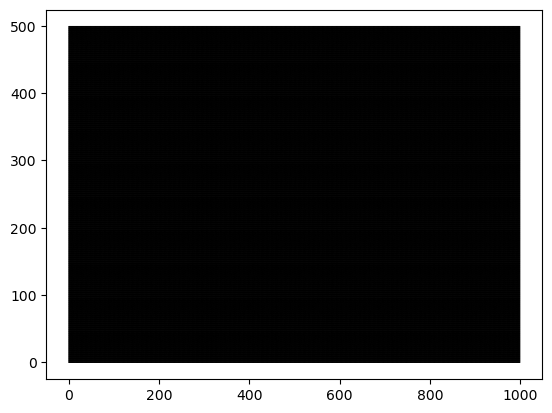

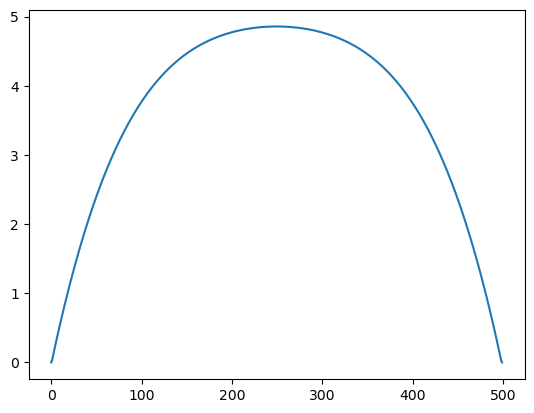

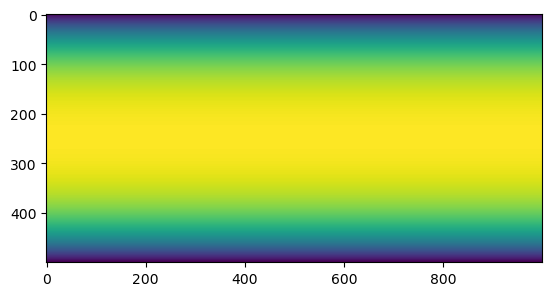

In [49]:
test_lb()